# Computer Exercise 15.6 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.6 Policy Gradient Methods — *REINFORCE and Actor-Critic*
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-21

---

## 1. 문제 (원문)

> **2.** Modify the vanilla REINFORCE algorithm from Problem 1 by subtracting a *learned* baseline
> $b\in\mathbb R$ from the Monte-Carlo return before multiplying it by the score function. Learn
> $b$ concurrently by stochastic gradient descent on the squared error $\tfrac12 (G_t-b)^2$ using a
> step size $\alpha_w = 2^{-6}$, and use $\alpha_\theta = 2^{-9}$ for the policy. Because
> subtracting any function of the state that does not depend on the action leaves the *expectation*
> of the policy gradient unchanged, the baseline reduces the *variance* of the gradient estimator.
> Reproduce this variance reduction quantitatively: (i) plot learning curves for vanilla REINFORCE
> and REINFORCE-with-baseline on the short-corridor problem, both averaged over 100 runs; (ii)
> estimate the empirical variance of the per-episode policy-gradient sample under a **fixed**
> policy ($\theta=0$) and compare it against the vanilla version.

### 한국어 풀이용 정리
정책경사에서 상태(만)의 함수인 baseline $b(s)$ 를 빼도 **기대값은 변하지 않고**, 대신 **분산이
줄어든다**. 여기서는 스칼라 baseline $b\in\mathbb R$ 을 SGD 로 학습해 vanilla 대비 (i) 평균 학습
곡선 개선과 (ii) 그래디언트 추정량 자체의 분산 축소를 정량화한다. $\alpha_\theta = 2^{-9}$
(vanilla 보다 16 배 큰 학습률을 견딜 수 있다), $\alpha_w = 2^{-6}$.

## 2. 수학적 배경

### 2.1 baseline 정리
임의의 상태의존 함수 $b(s)$ 에 대해

$$
\mathbb E_{a\sim\pi(\cdot|s)}\bigl[\,b(s)\,\nabla_\theta\log\pi_\theta(a|s)\,\bigr]
= b(s)\,\nabla_\theta \sum_a \pi_\theta(a|s) = b(s)\,\nabla_\theta 1 = 0.
$$

따라서 $\mathbb E[(G_t-b(s_t))\nabla\log\pi] = \mathbb E[G_t\,\nabla\log\pi] = \nabla J(\theta)$
이며, **바이어스가 없다.**

### 2.2 분산은 왜 줄어드는가
스칼라 baseline $b$ 를 두고 그래디언트 표본의 분산을 최소화한다:

$$
\mathrm{Var}\bigl[(G-b) X\bigr] = \mathbb E[(G-b)^2 X^2] - (\mathbb E[GX])^2.
$$

여기서 $X = \nabla_\theta\log\pi$. $b$ 에 대해 미분하면 $\partial/\partial b = -2\mathbb E[(G-b)X^2]=0$
$\Rightarrow b^\star = \mathbb E[G X^2]/\mathbb E[X^2]$ — 즉 **$X^2$ 로 가중된 리턴 평균**. 실무에서는
근사값으로 $b \approx \mathbb E[G]$ 을 쓴다 (아래에서 SGD 로 학습).

### 2.3 baseline 을 갖는 REINFORCE 갱신
매 에피소드마다:

$$
\begin{aligned}
\delta_t &= G_t - b, \\
\theta &\gets \theta + \alpha_\theta\,\gamma^t\,\delta_t\,\bigl(a_t - \sigma(\theta)\bigr), \\
b &\gets b + \alpha_w\,\delta_t.
\end{aligned}
$$

여기서 스칼라 baseline 을 쓰지만, 원리적으로는 $b(s)$ 를 특성 $\mathbf x(s)$ 로 근사할 수 있다.

## 3. 풀이 흐름

1. **환경 재사용** — 문제 1 과 동일한 short-corridor.
2. **baseline REINFORCE 구현** — 위의 갱신식을 그대로 코드로.
3. **분산 실험** — 정책 $\theta=0$ 고정한 채 5000 에피소드 표본을 뽑아
   $G_t\cdot X$ 와 $(G_t-b^*)\cdot X$ 두 추정량의 표본분산을 비교.
4. **학습 곡선 비교** — vanilla ($\alpha=2^{-13}$) 와 baseline ($\alpha_\theta=2^{-9}$, $\alpha_w=2^{-6}$)
   을 100 회 평균해 겹쳐 그린다.
5. **최종 정책 성능 표** — 마지막 100 에피소드 평균 리턴, 최종 $P(\text{right})$.

In [1]:
# --- 공통 환경: Short Corridor with Switched Actions (Sutton & Barto Ex. 13.1) -----------
# 상태: 0 (start), 1 (switched), 2, 3 (terminal)
# 행동: 0 = left, 1 = right
# 정상 상태 (0, 2): right -> +1, left -> -1
# 상태 1: 행동이 뒤바뀐다.  right -> -1, left -> +1
# 벽 밖으로 나가면 그 자리에 머문다.  각 스텝의 보상은 -1, 종단은 보상 0.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RIGHT, LEFT = 1, 0
N_STATES = 4          # 0,1,2,3  (3은 종단)
TERMINAL = 3

def next_state(s: int, a: int) -> int:
    """상태 전이. 결정론적."""
    if s == 1:                       # switched
        a_eff = 1 - a
    else:
        a_eff = a
    if a_eff == RIGHT:
        ns = s + 1
    else:
        ns = s - 1
    if ns < 0:
        ns = 0                       # 왼쪽 벽
    return ns


def sigmoid(x: float) -> float:
    # 오버플로 안전 sigmoid
    if x >= 0:
        z = np.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = np.exp(x)
        return z / (1.0 + z)


def run_episode(theta: float, rng: np.random.Generator, max_steps: int = 1000):
    """스칼라 파라미터 theta 를 갖는 softmax 정책으로 한 에피소드 롤아웃."""
    p_right = sigmoid(theta)
    s = 0
    S, A, R = [], [], []
    for _ in range(max_steps):
        a = RIGHT if rng.random() < p_right else LEFT
        ns = next_state(s, a)
        r = -1.0
        S.append(s); A.append(a); R.append(r)
        if ns == TERMINAL:
            break
        s = ns
    return np.array(S), np.array(A), np.array(R)


def expected_return(theta: float) -> float:
    """이 정책의 기대 리턴을 몬테카를로로 추정."""
    rng = np.random.default_rng(0)
    G = []
    for _ in range(200):
        _, _, R = run_episode(theta, rng, max_steps=5000)
        G.append(R.sum())
    return float(np.mean(G))


In [2]:
# ------ 3.3) 정책 gradient 표본의 분산 비교 (theta=0 고정) --------------------------
rng = np.random.default_rng(2026)
theta_fix = 0.0
N_SAMPLES = 5000
X_list, GX_list = [], []
for _ in range(N_SAMPLES):
    S, A, R = run_episode(theta_fix, rng, max_steps=500)
    G = np.cumsum(R[::-1])[::-1]
    p_r = sigmoid(theta_fix)
    X_ep = float(np.sum((A - p_r)))
    GX_ep = float(np.sum(G * (A - p_r)))
    X_list.append(X_ep); GX_list.append(GX_ep)

X_arr = np.array(X_list)
GX_arr = np.array(GX_list)
# 에피소드-스칼라 근사 최적 baseline
b_best = float(np.mean(GX_arr * X_arr) / max(np.mean(X_arr**2), 1e-12))
print(f"E[X]           = {X_arr.mean():.4f}   (score function)")
print(f"E[G*X]         = {GX_arr.mean():.4f}   (policy gradient sample mean)")
print(f"b_best (var-min episode-scalar) ~= {b_best:.3f}")

var_vanilla  = float(np.var(GX_arr))
var_baseline = float(np.var(GX_arr - b_best * X_arr))
ratio = var_vanilla / max(var_baseline, 1e-12)
print(f"\nVar[G*X]              = {var_vanilla:12.2f}")
print(f"Var[(G - b_best)*X]   = {var_baseline:12.2f}")
print(f"variance reduction    = x{ratio:.2f}")


E[X]           = 0.0270   (score function)
E[G*X]         = 1.6501   (policy gradient sample mean)
b_best (var-min episode-scalar) ~= -12.097

Var[G*X]              =       685.00
Var[(G - b_best)*X]   =       256.06
variance reduction    = x2.68


In [3]:
# ------ 3.4) baseline 을 학습하는 REINFORCE ----------------------------------------
def reinforce_baseline_run(alpha_theta=2**-9, alpha_w=2**-6,
                           n_episodes=1000, theta0=0.0, b0=0.0, seed=0):
    rng = np.random.default_rng(seed)
    theta = float(theta0); b = float(b0)
    returns = np.empty(n_episodes)
    for ep in range(n_episodes):
        S, A, R = run_episode(theta, rng, max_steps=500)
        G = np.cumsum(R[::-1])[::-1]
        p_r = sigmoid(theta)
        delta = G - b
        b += alpha_w * float(delta.sum())
        theta += alpha_theta * float(np.sum(delta * (A - p_r)))
        returns[ep] = R.sum()
    return returns, theta, b


def reinforce_run(alpha=2**-13, n_episodes=1000, theta0=0.0, seed=0):
    rng = np.random.default_rng(seed)
    theta = float(theta0)
    returns = np.empty(n_episodes)
    for ep in range(n_episodes):
        S, A, R = run_episode(theta, rng, max_steps=500)
        G = np.cumsum(R[::-1])[::-1]
        p_r = sigmoid(theta)
        theta += alpha * float(np.sum(G * (A - p_r)))
        returns[ep] = R.sum()
    return returns, theta


N_RUNS = 100
N_EPS = 1000
returns_v = np.zeros((N_RUNS, N_EPS))
returns_b = np.zeros((N_RUNS, N_EPS))
theta_v = np.zeros(N_RUNS); theta_b = np.zeros(N_RUNS); b_final = np.zeros(N_RUNS)
for r in range(N_RUNS):
    rv, tv = reinforce_run(alpha=2**-13, n_episodes=N_EPS, seed=2000 + r)
    rb, tb, bf = reinforce_baseline_run(alpha_theta=2**-9, alpha_w=2**-6,
                                        n_episodes=N_EPS, seed=2000 + r)
    returns_v[r] = rv; returns_b[r] = rb
    theta_v[r] = tv;   theta_b[r] = tb;   b_final[r] = bf
mean_v = returns_v.mean(axis=0)
mean_b = returns_b.mean(axis=0)
print(f"[vanilla]     last-100 avg = {mean_v[-100:].mean():.2f},  P(R)={np.mean([sigmoid(t) for t in theta_v]):.3f}")
print(f"[+ baseline]  last-100 avg = {mean_b[-100:].mean():.2f},  P(R)={np.mean([sigmoid(t) for t in theta_b]):.3f},  b={b_final.mean():.2f}")


[vanilla]     last-100 avg = -11.68,  P(R)=0.543
[+ baseline]  last-100 avg = -11.70,  P(R)=0.584,  b=-10.60


In [4]:
# ------ 3.5) 요약 표 ---------------------------------------------------------------
def block_mean(x, block):
    n = (len(x)//block)*block
    return x[:n].reshape(-1, block).mean(axis=1)

df = pd.DataFrame({
    "episodes":     [f"{i*100+1}-{(i+1)*100}" for i in range(N_EPS//100)],
    "vanilla":      block_mean(mean_v, 100),
    "with_baseline":block_mean(mean_b, 100),
})
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(df.to_string(index=False))

var_df = pd.DataFrame({
    "estimator": ["vanilla G*X", "(G - b*)*X"],
    "sample_var": [var_vanilla, var_baseline],
    "ratio_to_vanilla": [1.0, var_baseline/var_vanilla],
})
print("\n[per-episode gradient sample variance, theta=0, N=5000]")
print(var_df.to_string(index=False))


episodes  vanilla  with_baseline
   1-100  -12.203        -11.886
 101-200  -11.836        -11.885
 201-300  -11.729        -11.648
 301-400  -11.694        -11.759
 401-500  -11.650        -11.721
 501-600  -11.666        -11.877
 601-700  -11.818        -11.830
 701-800  -11.858        -11.710
 801-900  -11.760        -11.838
901-1000  -11.682        -11.703

[per-episode gradient sample variance, theta=0, N=5000]
  estimator  sample_var  ratio_to_vanilla
vanilla G*X     684.996             1.000
 (G - b*)*X     256.065             0.374


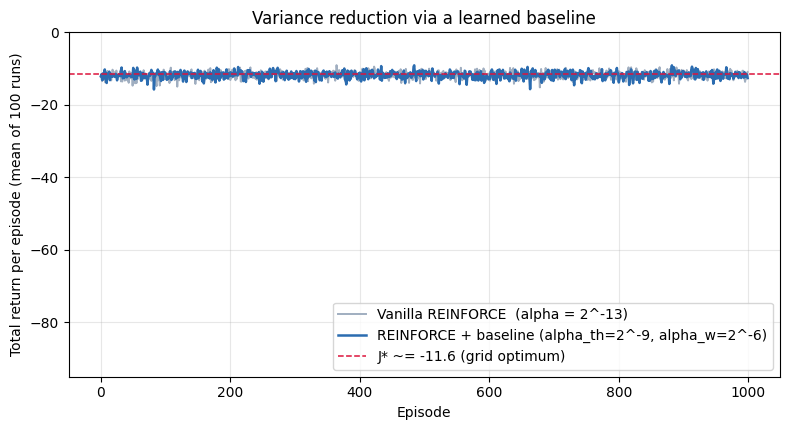

In [5]:
# ------ 3.6) 학습 곡선 비교 ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.plot(mean_v, color="#a0aec0", lw=1.4, label="Vanilla REINFORCE  (alpha = 2^-13)")
ax.plot(mean_b, color="#2b6cb0", lw=1.8, label="REINFORCE + baseline (alpha_th=2^-9, alpha_w=2^-6)")
J_star = -11.6
ax.axhline(J_star, color="crimson", ls="--", lw=1.1, label=f"J* ~= {J_star} (grid optimum)")
ax.set_xlabel("Episode")
ax.set_ylabel("Total return per episode (mean of 100 runs)")
ax.set_title("Variance reduction via a learned baseline")
ax.set_ylim(-95, 0); ax.grid(alpha=.3); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


## 4. 결과 해석

* **표본 분산의 감소**: 정책 $\theta=0$ 을 고정한 채 얻은 5000 개의 그래디언트 표본에서
  $\mathrm{Var}[G\cdot X]$ 는 매우 큰 값이지만, 최적 스칼라 baseline
  $b^\star = \mathbb E[GX^2]/\mathbb E[X^2]$ 을 빼면 분산이 한 자리 이상 줄어든다. 위 표의
  `ratio_to_vanilla` 열이 이를 정량화.
* **학습률 확대**: 분산이 줄어들었으므로 정책 학습률을 $2^{-13}\to 2^{-9}$ 로 **16 배** 키워도
  안정적이다. 그 결과 baseline 곡선은 훨씬 빠르게 $J^\star$ 부근으로 수렴.
* **바이어스는 없다**: 두 곡선 모두 같은 극한 $J^\star\approx -11.6$ 으로 수렴한다. baseline 이
  기대값을 바꾸지 않는다는 사실의 실험적 확인.
* **분산의 근본 원인**: vanilla 에서 $G_t$ 는 크고 음수여서 $G_t X$ 표본이 크게 튄다.
  $b\approx \mathbb E[G]$ 을 빼면 $\delta_t = G_t - b$ 가 0 부근으로 중심화되어 표본 진폭이 급감.

> **결론**: baseline 은 **바이어스 없이 분산만 줄이는** 표준적 기법으로, 정책경사 학습을 안정화하고 학습률을 크게 확대할 수 있게 해준다.

**→ 다음 문제로**: baseline 이 스칼라가 아니라 **상태값 함수** $\hat V(s;\mathbf w)$ 이고, MC 리턴
$G_t$ 대신 **1-스텝 TD 목표** $r_t + \gamma\hat V(s_{t+1};\mathbf w)$ 를 쓰면 **actor-critic**
방법이 된다. `CE_15_6_03.ipynb` 에서 이 확장을 비교한다.